# Получение информации по поверке средств измерения в системе "Аршин" через API

Данный гайд показывает как можно получить информацию из системы "Аршин" и проверить информацию по поверке средств измерения используя стандартные библиотеки для работы с данными. Система имеет OEI-API.

OEI-API (Application Programming Interface) - программный интерфейс, предназначенный для предоставления в автоматическом режиме сведений о результатах поверок СИ, содержащихся в Федеральном информационном фонде по обеспечению единства измерений.

API обеспечивает возможность формирования и передачу запроса, и последующее получение результатов запроса в формате JSON. Данная возможность обеспечивается путем предоставления доступа к синхронным интерфейсам с использованием протокола HTTP 1.1.

## Ограничения на этапе тестирования и отладки:

* Выдача ограничена 10000 записей за 1 запрос (LIMIT 10000), планируется отдавать до 3млн. записей
* Вывод данных возможен в виде php array, json или xml. Устанавливается параметром &export_type (1 - php array; 2 - json; 3 - xml)
* Принудительное время выполнения скрипта ограничено 5 минутами. Оптимизируйте запрос под Ваши потребности.
* Планируется возвращение данных в виде сжатого массива
* Регистр при вводе параметр значеняи не имеет
* Все параметры (кроме ?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a), указанные ниже, являются необязательными. Допустимы любые их комбиации
* Параметр regkey=d37e5f9c2df49556a580b1c3dc8dcc7a - ключ доступа для тестирования и отладки. Полноценный рабочий regkey предоставляется бонусом при приобретении годовой подписки на аналитику и будет доступен в профиле пользователя.

Подключим необходимые модули

In [ ]:
import pandas as pd
import requests

Зададим точку входа для получения данных

In [ ]:
url = 'http://731163-cj72200.tmweb.ru/vri/'

Проверим, что система "Аршин" нам отвечает

In [ ]:
r = requests.get(url)
r

<Response [200]>

## Параметры запроса
&export_type - тип выходного массива данных.
1 - php array; 2 - json (для кодирования использована стандартаня PHP функция json_encode(), для декодирования следует использовать json_decode()); 3 - xml. Пример вывода данных в xml формате
http://731163-cj72200.tmweb.ru/vri/?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a&vri_id_from=147222222&vri_id_to=147222322&export_type=3

&vri_id - id поверки.
Число в конце ccылки на карточку поверки в ФГИС АРШИН. Например для поверки https://fgis.gost.ru/fundmetrology/cm/results/1-179725564 это число 179725564

&vri_id_from - id поверки от.
Нижняя граница для поиска поверок по id. Например, при &vri_id_from=12345 будут выводиться только те поверки, чей id больше или равен 12345

&vri_id_to - id поверки до.
Верхняя граница для поиска поверок по id. Например, при &vri_id_to=99999 будут выводиться только те поверки, чей id меньше или равен 99999

&mi_number - Заводской номер СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска заводсого номера '05359326' необходимо задать &mi_number=05359326

&mi_modification - Модификация СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска модификации СИ 'Меркурий 230 ART-03 PQRSIDN' необходимо задать &mi_modification=Меркурий 230 ART-03 PQRSIDN

&mitypeTitle - Наименование СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска наименования СИ 'Счетчики электрической энергии трёхфазные статические' можно задать &mitypeTitle=электрической энергии

&mit_MPISI - Межповерочный интервал в соотвествии с ОТ.
Текствое поле. Можно указывать часть фразы. Например, для поиска такой фразы '4 года - для гор.воды; 6 лет - хол.' можно задать &mit_MPISI=6 лет - хол

&mit_id - id типа СИ в реестре СИ АРШИН.
Поле типа int. Ищется полное совпадение. Например: &mit_id=347162

&mitypeType - Обозначение типа СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска обозначения типа СИ 'Меркурий 230' можно задать &mitypeType=меркурий

&mitypeNumber - № типа СИ в госреестре.
Текствое поле. Ищется полное совпадение. Например: &mitypeNumber=23345-07

&org_title - Наименование организации-поверителя.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ЭНЕРТЕСТ(ООО ЭНЕРТЕСТ)' можно задать &org_title=энертест

&mi_manufactureYear - Год выпуска СИ.
Целое число. Ищется полное совпадение. Например: &mi_manufactureYear=2009

&mi_signCipher - Условный шифр знака поверки.
Текстовое поле. Ищется полное совпадение. Например: &mi_signCipher=ГЦН

&docTitle - Наиенование методики поверки
Текстовое поле. Можно указывать часть фразы. Например, для документа ГОСТ OIML R 76-1-2011: &docTitle=ГОСТ OIML R 76

&mi_Owner_name - Владелец СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Газпром трансгаз Ухта' можно задать &mi_Owner_name=ООО Газпром

&mit_owner_CountrySI - Страна производства.
Текстовое поле. Ищется полное совпадение. Например: &mit_owner_CountrySI=россия

&mit_owner_SettlementSI - Населенный пункт (производства).
Текствое поле. Можно указывать часть слова или словосочетания. Например, для поиска СИ, произведенных в Москве: &mit_owner_SettlementSI=моск

&mit_owner_ManufacturerSI - Производитель СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Спутник' достаточно задать &mit_owner_ManufacturerSI=Спутник

&poverka_valid_date - Поверка действительна до
Текствое поле. Указывается дата окончания поверки в формате d.m.Y (например - &poverka_valid_date=17.05.2021). Ищется полное совпадение.

&poverka_publication_date - Дата публикации.
Текствое поле. Указывается дата публикации в формате d.m.Y (например - &poverka_publication_date=17.05.2021). Ищется полное совпадение.

&poverka_verification_date - Дата поверки.
Текствое поле. Указывается дата поверки в формате d.m.Y (например - &poverka_verification_date=12.03.2020). Ищется полное совпадение.

&poverka_verification_month - Месяц поверки.
Текствое поле. Указывается месяц поверки с годом в формате m.Y (например - &poverka_verification_month=03.2020). Ищется полное совпадение.

&poverka_verification_year - Год поверки.
Текствое поле. Указывается год в формате Y (например - &poverka_verification_year=2020). Ищется полное совпадение.

&poverka_vriType - Тип поверки.
Числовое поле. 2 - периодическая; 1 - первичная; Например, при такой записи - &poverka_vriType=2 будут отображены только периодические поверки.

## Пример запроса
Давайте запросим все поверенные приборы в МАИ, которые были сделаны в России и поверены в 2021 году.

Запрос займет некоторое время, а также не забывайте указывать регистрационный ключ (ключ в примере получен как тестовый и может не содержать всей информации из реестра)

In [ ]:
keys = {'regkey': 'd37e5f9c2df49556a580b1c3dc8dcc7a',
        'mi_Owner_name': 'Новосибирский авиационный завод',
        #'poverka_verification_year': '2024',
        'export_type': '2'}

r = requests.get(url, params=keys)
r

<Response [200]>

Прочитаем данные из запроса

In [ ]:
try:
    json = r.json()
except ValueError:
    print("Oops!")

Переведем данные в удобный нам формат Pandas DataFrame

In [ ]:
df = pd.DataFrame(json)
df

,id,vri_id,mi_number,mi_modification,mi_manufactureYear,mi_signCipher,mi_Owner_name,org_title,fsa_ral_regNumbers_regNumber,mitypeNumber,...,vriType,result_docnum,result_doc_type,additional_info,means_npe,means_uve,means_mieta,means_ses,means_mis,means_reagent
0,1,41942091,7727,Е6-24/1,None,Н,Филиа...,Запад...,RA.RU...,25405-08,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,56598.14.3Р.00198402 56598-14 Магазины сопроти...,,2303-68 Киловольтметры электростатические (№53...,
1,2,43465375,5299,КИСС-03,2018,Н,Филиа...,Запад...,RA.RU...,20641-11,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,54727.13.2Р.00117862 54727-13 Компараторы-кали...,,1162-58 Катушки электрического сопротивления и...,
2,3,42536520,12480,М244,1970,Н,Филиа...,Запад...,RA.RU...,2373-68,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,55804.13.1Р.00108519 55804-13 Калибраторы мног...,,,
3,4,38122750,1401,нет м...,2014,Н,Новос...,Запад...,RA.RU...,47965-11,...,Периодическая,C-Н/1...,Извещение о непригодности,,,3.1.ZZН.0046.2012 ГЭЕ длины 1 разряда в диапаз...,,,,
4,5,45933349,651358,КО-1,None,Н,Новос...,Запад...,RA.RU...,868-72,...,Периодическая,C-Н/1...,Извещение о непригодности,,,3.1.ZZН.0050.2013 ГЭЕ плоского угла 2 разряда ...,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,97,354894349,24211,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Периодическая,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
97,98,354964012,24210,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Периодическая,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
98,99,355973023,24210,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Первичная поверка,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
99,100,355973024,24211,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Первичная поверка,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,


In [ ]:
df['mitypeURL'][66]

'https://fgis.gost.ru/fundmetrology/registry/4/items/345372'

# Практическое задания
* Попробуйте получить данные о манометрах, поверенных в ЦАГИ имени Н.Е. Жуковского
* Проверьте есть ли в МАИ поверенные расходомеры
* Проверьте свой домашний счетчик воды (горячей или холодной) на наличие поверки, если конечно счетчик у вас установлен &#x1F600; и он был поверен после 24.09.2020 года (именно с этой даты все организации обязаны передавать данные о поверке в единую систему).

Все данные по п.1/2 обработайте и сведите в Pandas Dataframe в формат удобный для датасета по оценке запросов на поверку средств измерения

Постройте аналитику по полученным данным.

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

url = 'http://731163-cj72200.tmweb.ru/vri/'

REGKEY = 'd37e5f9c2df49556a580b1c3dc8dcc7a'

def get_data(params):
    params['regkey'] = REGKEY
    params['export_type'] = '2'

    response = requests.get(url, params=params)

    print("STATUS:", response.status_code)

    try:
        data = response.json()
        return pd.DataFrame(data)

    except Exception as e:
        print("Ошибка:", e)
        return pd.DataFrame()


In [ ]:
#МАНОМЕТРЫ В ЦАГИ

params_manometers = {
    'mitypeTitle': 'манометр',
    'org_title': 'ЦАГИ'
}

df_manometers = get_data(params_manometers)

print('\nМанометры в ЦАГИ:')
print(df_manometers.head())

STATUS: 200

Манометры в ЦАГИ:
   id      vri_id mi_number mi_modification mi_manufactureYear mi_signCipher  \
0   1  1173224226      01-К                               None           АОЛ   
1   2  1173224227      02-К                               None           АОЛ   
2   3  1173224228      03-К                               None           АОЛ   
3   4  1173224229      04-К                               None           АОЛ   
4   5  1173224230      05-К                               None           АОЛ   

  mi_Owner_name org_title fsa_ral_regNumbers_regNumber mitypeNumber  ...  \
0                ФГУП ...                     РОСС ...     55372-13  ...   
1                ФГУП ...                     РОСС ...     55372-13  ...   
2                ФГУП ...                     РОСС ...     55372-13  ...   
3                ФГУП ...                     РОСС ...     55372-13  ...   
4                ФГУП ...                     РОСС ...     55372-13  ...   

       vriType result_docnum   

In [ ]:
#РАСХОДОМЕРЫ В МАИ

params_flowmeters = {
    'mitypeTitle': 'расходомер',
    'mi_Owner_name': 'МАИ'
}

df_flowmeters = get_data(params_flowmeters)

print('\nРасходомеры в МАИ:')
print(df_flowmeters.head())


STATUS: 200

Расходомеры в МАИ:
   id     vri_id mi_number mi_modification mi_manufactureYear mi_signCipher  \
0   1  427990506  M1520...         EL-FLOW               2015           ДШЛ   
1   2  427990697  M1520...         EL-FLOW               2015           ДШЛ   
2   3  427990440  M1721...         EL-FLOW               2017           ДШЛ   
3   4  427990539  M1721...         EL-FLOW               2017           ДШЛ   
4   5  172632977    161954        Питер...               None            БЯ   

  mi_Owner_name org_title fsa_ral_regNumbers_regNumber mitypeNumber  ...  \
0      НИИ П...  ОБЩЕС...                     RA.RU...     25705-10  ...   
1      НИИ П...  ОБЩЕС...                     RA.RU...     25705-10  ...   
2      НИИ П...  ОБЩЕС...                     RA.RU...     64700-16  ...   
3      НИИ П...  ОБЩЕС...                     RA.RU...     64700-16  ...   
4        МАИ+3Н  ФЕДЕР...                     RA.RU...     46814-11  ...   

         vriType result_docnum      

In [ ]:
#ДОМАШНИЙ СЧЁТЧИК ВОДЫ

my_counter_number = '111022134'

params_counter = {
    'mi_number': my_counter_number
}

df_counter = get_data(params_counter)
print(df_counter.head())


STATUS: 200
   id      vri_id mi_number mi_modification mi_manufactureYear mi_signCipher  \
0   1  1175636840  11102...        VLF т...               None           ДМФ   

  mi_Owner_name org_title fsa_ral_regNumbers_regNumber mitypeNumber  ...  \
0                ООО &...                     RA.RU...     58362-14  ...   

       vriType result_docnum            result_doc_type additional_info  \
0  Без статуса      4/20/...  Извещение о непригодности                   

  means_npe                                          means_uve means_mieta  \
0            3.2.ZВУ.1021.2018 Эталон единицы объёмного рас...               

  means_ses means_mis means_reagent  
0                                    

[1 rows x 34 columns]


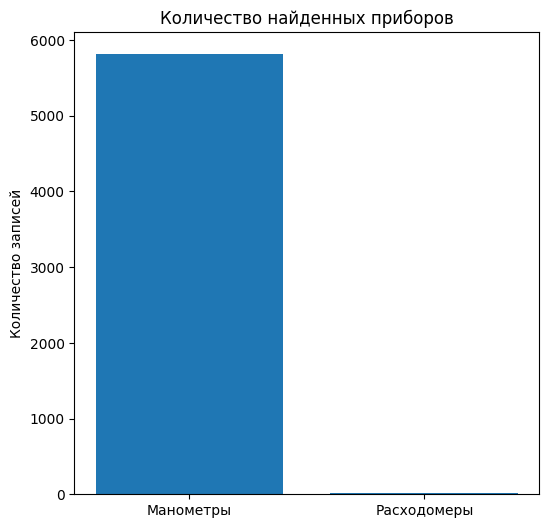

In [ ]:
counts = [
    len(df_manometers),
    len(df_flowmeters)
]

labels = [
    'Манометры',
    'Расходомеры'
]

plt.figure(figsize=(6, 6))

plt.bar(labels, counts)

plt.title('Количество найденных приборов')

plt.ylabel('Количество записей')

plt.show()

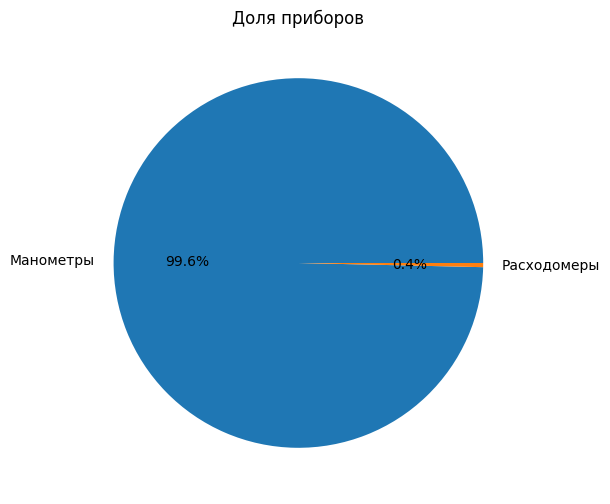

In [ ]:
plt.figure(figsize=(6, 6))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Доля приборов')

plt.show()

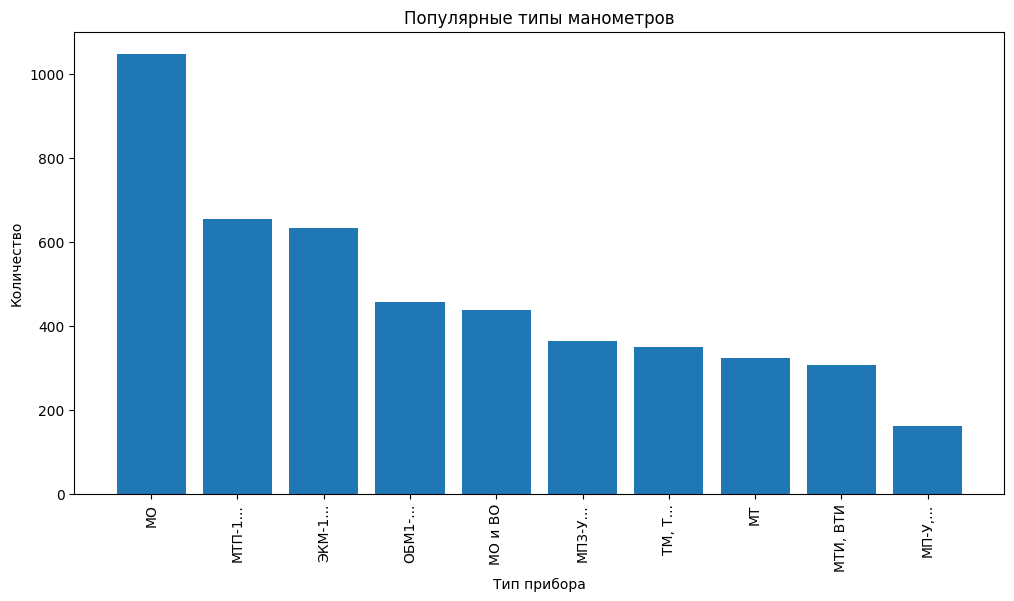

In [ ]:
if not df_manometers.empty:

    if 'mitypeType' in df_manometers.columns:

        top_types = (
            df_manometers['mitypeType']
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(12, 6))

        plt.bar(top_types.index,
                top_types.values)

        plt.title('Популярные типы манометров')
        plt.xlabel('Тип прибора')
        plt.ylabel('Количество')

        plt.xticks(rotation=90)

        plt.show()

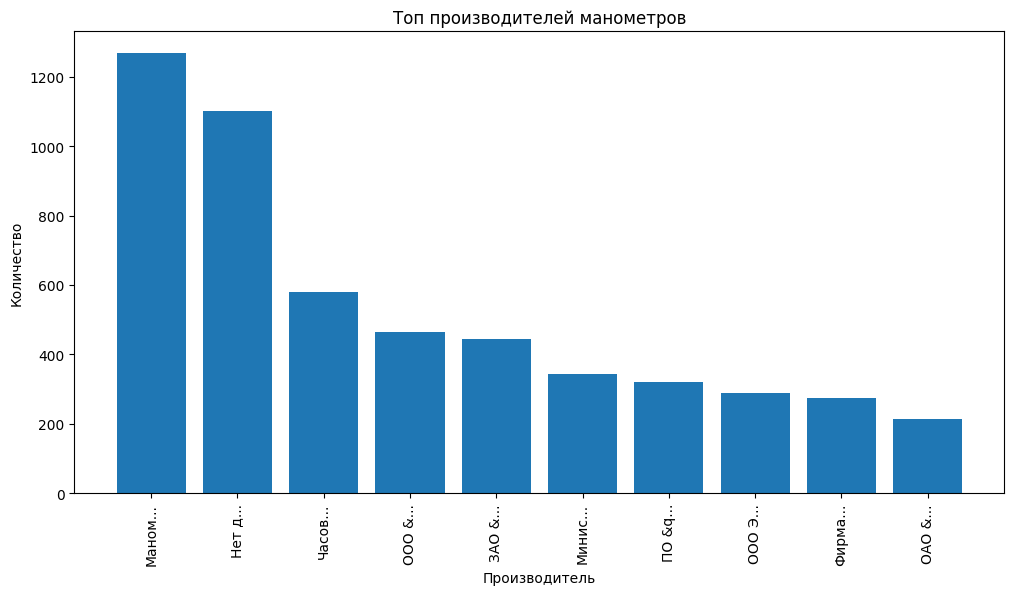

In [ ]:
if not df_manometers.empty:

    if 'mit_owner_ManufacturerSI' in df_manometers.columns:

        top_manufacturers = (
            df_manometers['mit_owner_ManufacturerSI']
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(12, 6))

        plt.bar(top_manufacturers.index,
                top_manufacturers.values)

        plt.title('Топ производителей манометров')
        plt.xlabel('Производитель')
        plt.ylabel('Количество')

        plt.xticks(rotation=90)

        plt.show()

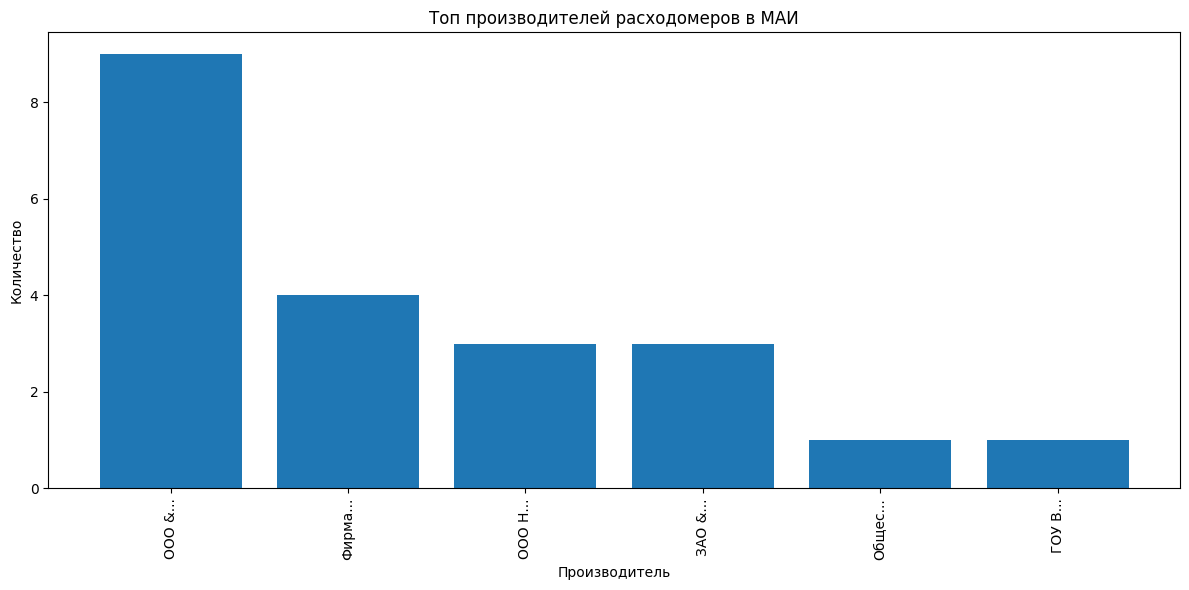

In [ ]:
if not df_flowmeters.empty:

    if 'mit_owner_ManufacturerSI' in df_flowmeters.columns:

        top_flow_manufacturers = (
            df_flowmeters['mit_owner_ManufacturerSI']
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(12, 6))

        plt.bar(
            top_flow_manufacturers.index,
            top_flow_manufacturers.values
        )

        plt.title('Топ производителей расходомеров в МАИ')

        plt.xlabel('Производитель')

        plt.ylabel('Количество')

        plt.xticks(rotation=90)

        plt.tight_layout()

        plt.show()

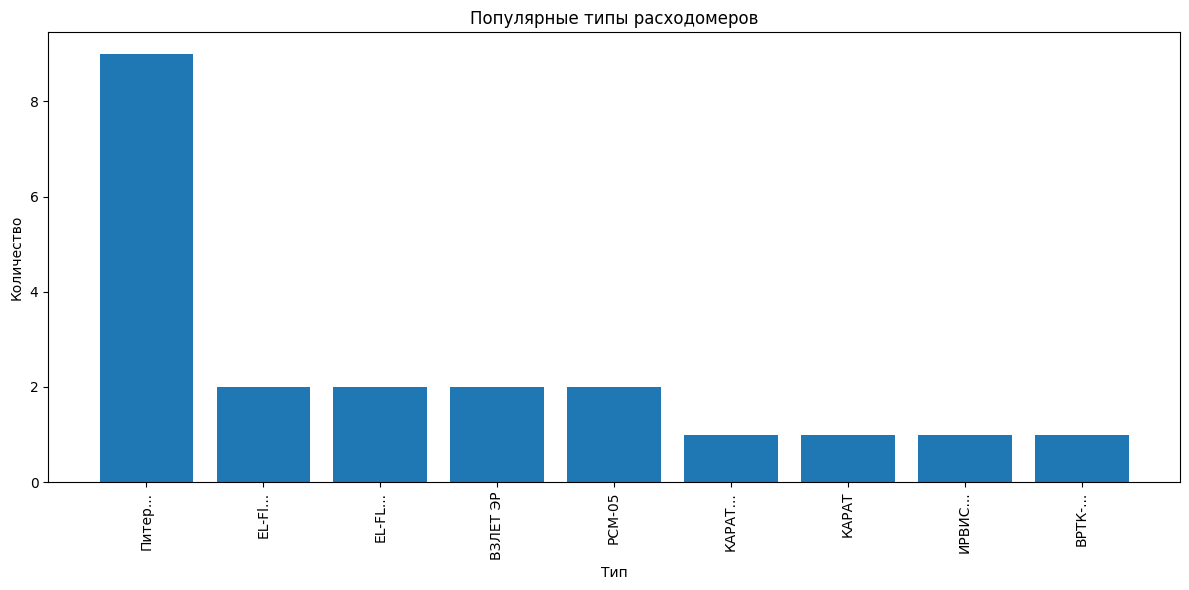

In [ ]:
if not df_flowmeters.empty:

    if 'mitypeType' in df_flowmeters.columns:

        top_flow_types = (
            df_flowmeters['mitypeType']
            .value_counts()
            .head(10)
        )

        plt.figure(figsize=(12, 6))

        plt.bar(
            top_flow_types.index,
            top_flow_types.values
        )

        plt.title('Популярные типы расходомеров')

        plt.xlabel('Тип')

        plt.ylabel('Количество')

        plt.xticks(rotation=90)

        plt.tight_layout()

        plt.show()